# Remote custom Gaussian-process model — cloudpickle experiment

**Goal:** Send a scientist-defined PyTorch class (`ConstraintPrior`) from Jupyter to an independent Xopt HTTP server **without installing that custom class on the server**. This notebook intentionally uses the experimental `cloudpickle_xopt.http.HTTPGenerator` instead of upstream serialization.

**Why this matters:** Scientists often define models directly in notebooks. Ordinary class-by-name reconstruction can fail when the server runs in another Python process or on another node. Cloudpickle can transport many such Python objects, including notebook-defined classes, provided compatible Python libraries exist on the server.

**Development:** Start `python -m uvicorn cloudpickle_xopt.server:app --host 127.0.0.1 --port 8002` in a separate terminal, then run this notebook.

**Target (different nodes):** Place the backend in a trusted Docker/Kubernetes environment and set `XOPT_HTTP_URL=http://SERVER_HOST:8002` for Jupyter. The server must have compatible Xopt, PyTorch, GPyTorch, and cloudpickle dependencies. Cloudpickle **can execute arbitrary code during deserialization**: this is a trusted-code experiment, not a service to expose to arbitrary clients. Network restrictions and authentication are required before broader deployment.

**Math intuition:** A Gaussian process (GP) represents uncertain functions with a mean (best current prediction) and covariance/kernel (how values at different `x` positions are related). A *periodic kernel* expresses repeating behavior. A *prior mean* injects an educated guess about a function before data are fitted. The example's `y(x)` is an objective to **maximize**, while `c(x) < 0` is a constraint: a candidate should have high `y` and satisfy the constraint. `ConstraintPrior` provides a custom prior mean for `c`.


**Cell guide — Import the **experimental cloudpickle** HTTPGenerator. Set `XOPT_HTTP_URL` to a remote server address when running across nodes; the default local development port is 8002.


In [1]:
from cloudpickle_xopt.http import HTTPGenerator

import os
SERVER_URL = os.environ.get("XOPT_HTTP_URL", "http://127.0.0.1:8002")
print("HTTPGenerator server:", SERVER_URL)

HTTPGenerator server: http://127.0.0.1:8002


**Cell guide — Import expected improvement (a Bayesian optimization acquisition method), GP model construction, periodic kernels, and PyTorch/Pandas. VOCS says maximize `y` while requiring `c < 0`; the decision variable `x` lies between 0 and 1.


In [2]:
from xopt.generators.bayesian.expected_improvement import ExpectedImprovementGenerator
from xopt.generators.bayesian.models.standard import StandardModelConstructor
from gpytorch.kernels import PeriodicKernel, ScaleKernel

import matplotlib.pyplot as plt
import pandas as pd
import torch
from xopt.vocs import VOCS

# Ignore all warnings
import warnings

warnings.filterwarnings("ignore")

my_vocs = VOCS(
    variables={"x": [0, 1]},
    objectives={"y": "MAXIMIZE"},
    constraints={"c": ["LESS_THAN", 0]},
)

/home/ernesto/controls/package/anaconda3/envs/xopt-http-dev/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


**Cell guide — Define the known toy functions: `y(x)=sin(2πx)` is the quantity we want to maximize, and `c(x)=5 cos(2πx+0.25)` must be negative to satisfy the constraint. Plot their curves and three starting measurements. These formulas simulate observations; they are not a real physics model.


<Axes: >

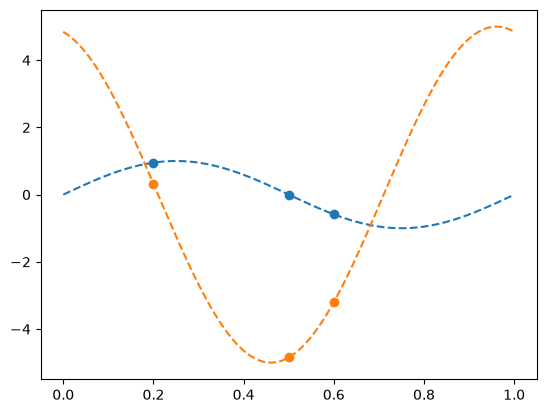

In [3]:
# define test functions
def y(x):
    return torch.sin(2 * 3.14 * x)


def c(x):
    return 5.0 * torch.cos(2 * 3.14 * x + 0.25)


test_x = torch.linspace(*torch.tensor(torch.tensor(my_vocs.bounds).flatten()), 100)

# define training data to pass to the generator
train_x = torch.tensor((0.2, 0.5, 0.6))
train_y = y(train_x)
train_c = c(train_x)

training_data = pd.DataFrame({"x": train_x.numpy(), "y": train_y.numpy(), "c": train_c})


def plot_ground_truth():
    fig, ax = plt.subplots()
    ax.plot(test_x, y(test_x), "--C0")
    ax.plot(test_x, c(test_x), "--C1")
    ax.plot(train_x, train_y, "oC0")
    ax.plot(train_x, train_c, "oC1")

    return ax


plot_ground_truth()

# Custom kernel definition
In this example we know that the target optimization function is periodic, so it
makes sense to use a periodic kernel for the GP model with no noise. Here we define a
function to create that model. Note that because we are optimizing a problem with no noise we set `use_low_noise_prior=True` in the GP model constructor.

**Cell guide — Build the first GP model with a **periodic covariance kernel** for the objective. A kernel encodes how similar function values are at nearby or periodically related `x` positions. The cloudpickle HTTPGenerator sends the generator to the server when a session is created.


In [4]:
# note the creation of options beforehand
# specify a periodic kernel for each output (objectives and constraints)
covar_module = {"y": ScaleKernel(PeriodicKernel())}
gp_constructor = StandardModelConstructor(
    covar_modules=covar_module, use_low_noise_prior=True
)
local_generator = ExpectedImprovementGenerator(vocs=my_vocs, gp_constructor=gp_constructor)
generator = HTTPGenerator(base_url=SERVER_URL, generator=local_generator)
generator

HTTPGenerator(returns_id=False, supports_batch_generation=True, supports_no_objective=True, supports_single_objective=True, supports_multi_objective=False, supports_constraints=True, supports_discrete_variables=True, supports_contextual_variables=True, vocs=VOCS(variables={'x': ContinuousVariable(dtype=None, default_value=None, domain=[0.0, 1.0])}, objectives={'y': MaximizeObjective(dtype=None)}, constraints={'c': LessThanConstraint(dtype=None, value=0.0)}, constants={}, observables={}), data=None, base_url='http://127.0.0.1:8002', generator=ExpectedImprovementGenerator(returns_id=False, supports_batch_generation=True, supports_no_objective=True, supports_single_objective=True, supports_multi_objective=False, supports_constraints=True, supports_discrete_variables=True, supports_contextual_variables=True, vocs=VOCS(variables={'x': ContinuousVariable(dtype=None, default_value=None, domain=[0.0, 1.0])}, objectives={'y': MaximizeObjective(dtype=None)}, constraints={'c': LessThanConstraint(

**Cell guide — Send initial measurements to the server. `pull()` copies the current generator state back into Jupyter; `train_model()` and `visualize_model()` below run **locally on the snapshot**, not as remote HTTP operations.


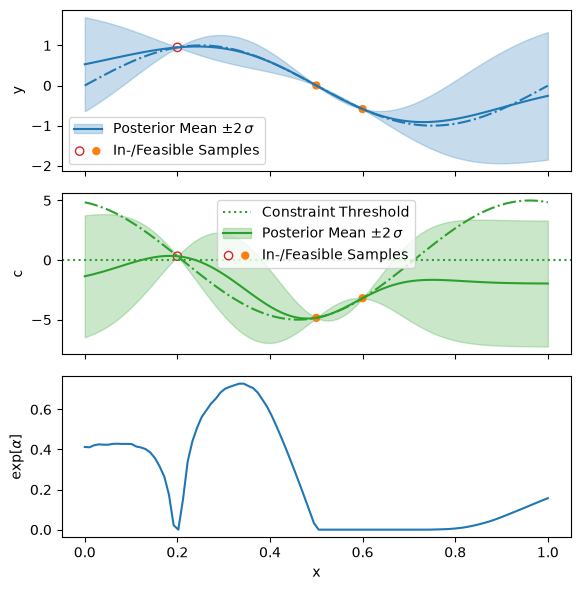

In [5]:
# view custom model from data
generator.add_data(training_data)
# Fetch a local snapshot for visualization and model inspection.
# train_model() below executes locally on the snapshot, NOT over HTTP.
mirror = generator.pull()
model = mirror.train_model()

fig, ax = mirror.visualize_model(n_grid=len(test_x))
# plot ground truth
ax[0, 0].plot(test_x, y(test_x), "C0-.")
ax[1, 0].plot(test_x, c(test_x), "C2-.");

**Cell guide — Inspect the locally trained GP model object. A GP estimates a function and its uncertainty from sparse measurements.


In [6]:
model

ModelListGP(
  (models): ModuleList(
    (0): SingleTaskGP(
      (likelihood): GaussianLikelihood(
        (noise_covar): HomoskedasticNoise(
          (noise_prior): GammaPrior()
          (raw_noise_constraint): GreaterThan(1.000E-04)
        )
      )
      (mean_module): ConstantMean()
      (covar_module): ScaleKernel(
        (base_kernel): PeriodicKernel(
          (raw_lengthscale_constraint): Positive()
          (raw_period_length_constraint): Positive()
        )
        (raw_outputscale_constraint): Positive()
      )
      (outcome_transform): Standardize()
      (input_transform): Normalize()
    )
    (1): SingleTaskGP(
      (likelihood): GaussianLikelihood(
        (noise_covar): HomoskedasticNoise(
          (noise_prior): GammaPrior()
          (raw_noise_constraint): GreaterThan(1.000E-04)
        )
      )
      (mean_module): ConstantMean()
      (covar_module): RBFKernel(
        (lengthscale_prior): LogNormalPrior()
        (raw_lengthscale_constraint): Greater

**Cell guide — Request one new candidate from the remote expected-improvement generator. This is the first end-to-end remote suggestion for the periodic-kernel setup.


In [7]:
# get the next point from the generator
generator.generate(1)

[{'x': 0.3288264566507414}]

## Custom prior mean function
Here we assume we have some knowledge of the ground truth function, which we can take
 advantage of to speed up optimization. This "prior mean" function is specified by a
 pytorch module. A mean function should reduce a (batch) x n x d-dimensional input into 
 a (batch) x n dimensional output.

**Cell guide — Close the first remote session. Define `ConstraintPrior` **inside this notebook** as a PyTorch module returning a prior guess for the constraint function. This notebook-defined class is precisely what the standard cross-process reconstruction struggled with; cloudpickle transports it without a shared custom module.


In [8]:
# Finish the periodic-kernel experiment before creating a new Generator.
generator.finalize()

class ConstraintPrior(torch.nn.Module):
    def forward(self, X):
        return c(X).squeeze(dim=-1)


gp_constructor = StandardModelConstructor(
    mean_modules={"c": ConstraintPrior()}, use_low_noise_prior=True
)
local_generator = ExpectedImprovementGenerator(
    vocs=my_vocs,
    gp_constructor=gp_constructor,
)
generator = HTTPGenerator(base_url=SERVER_URL, generator=local_generator)

**Cell guide — Ingest the same observations into the **new** cloudpickle session, then pull a snapshot for local model training and plotting. The server has received the notebook-defined prior as part of the serialized generator.


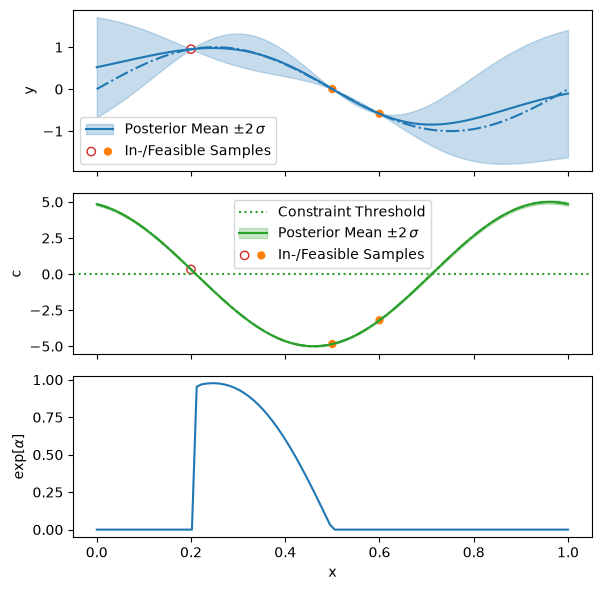

In [9]:
# view custom model from data
generator.add_data(training_data)
# Fetch a local snapshot for visualization and model inspection.
# train_model() below executes locally on the snapshot, NOT over HTTP.
mirror = generator.pull()
model = mirror.train_model()

fig, ax = mirror.visualize_model(n_grid=len(test_x))
# plot ground truth
ax[0, 0].plot(test_x, y(test_x), "C0-.")
ax[1, 0].plot(test_x, c(test_x), "C2-.");

**Cell guide — Inspect the locally trained GP model with the custom prior mean.


In [10]:
model

ModelListGP(
  (models): ModuleList(
    (0): SingleTaskGP(
      (likelihood): GaussianLikelihood(
        (noise_covar): HomoskedasticNoise(
          (noise_prior): GammaPrior()
          (raw_noise_constraint): GreaterThan(1.000E-04)
        )
      )
      (mean_module): ConstantMean()
      (covar_module): RBFKernel(
        (lengthscale_prior): LogNormalPrior()
        (raw_lengthscale_constraint): GreaterThan(2.500E-02)
      )
      (outcome_transform): Standardize()
      (input_transform): Normalize()
    )
    (1): SingleTaskGP(
      (likelihood): GaussianLikelihood(
        (noise_covar): HomoskedasticNoise(
          (noise_prior): GammaPrior()
          (raw_noise_constraint): GreaterThan(1.000E-04)
        )
      )
      (mean_module): CustomMean(
        (_model): ConstraintPrior()
        (input_transformer): Normalize()
        (outcome_transformer): Standardize()
      )
      (covar_module): RBFKernel(
        (lengthscale_prior): LogNormalPrior()
        (raw_le

**Cell guide — Inspect PyTorch model parameters. These are the learned/learnable numerical values of the GP model, not the HTTP session configuration.


In [11]:
list(model.named_parameters())

[('models.0.likelihood.noise_covar.raw_noise',
  Parameter containing:
  tensor([-21.6878], requires_grad=True)),
 ('models.0.mean_module.raw_constant',
  Parameter containing:
  tensor(0.0015, requires_grad=True)),
 ('models.0.covar_module.raw_lengthscale',
  Parameter containing:
  tensor([[0.1986]], requires_grad=True)),
 ('models.1.likelihood.noise_covar.raw_noise',
  Parameter containing:
  tensor([-19.9708], requires_grad=True)),
 ('models.1.covar_module.raw_lengthscale',
  Parameter containing:
  tensor([[4.0750]], requires_grad=True))]

**Cell guide — Generate a candidate **on the server**, pull the remote generator state, and assert that the custom `ConstraintPrior` survived transport. Finally close the remote session. The printed point may differ between runs.


In [12]:
# The server trained the model during generate(); pull to inspect the
# server's resulting state and confirm the custom prior survived.
points = generator.generate(1)
print("Remote suggested point:", points)
mirror = generator.pull()
print("Recovered prior type:", type(mirror.gp_constructor.mean_modules["c"]).__name__)
assert isinstance(mirror.gp_constructor.mean_modules["c"], ConstraintPrior)
generator.finalize()
print("Remote prior-mean session finalized")

Remote suggested point: [{'x': 0.24605887899441087}]
Recovered prior type: ConstraintPrior
Remote prior-mean session finalized
